# Importing libraries

In [375]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import scipy.stats as stats
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import shapiro
import statsmodels.api as sm

# Data loading

In [376]:
df = pd.read_csv("AirbnbEurope.csv")

# Filling missing values

In [377]:
# Missing values here occur when 'number_of_reviews' is 0, so 0 is factually correct.
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)

# Ratings are often skewed; the median provides a "typical" score without being pulled by outliers.
df['review_scores_rating'] = df['review_scores_rating'].fillna(df['review_scores_rating'].median())

# Fill bathrooms, bedrooms, beds nulls based on 'accommodates' group median, then global median
df['bathrooms'] = df.groupby('accommodates')['bathrooms'].transform(lambda x: x.fillna(x.median()))
df['bathrooms'] = df['bathrooms'].fillna(df['bathrooms'].median())

df['bedrooms'] = df.groupby('accommodates')['bedrooms'].transform(lambda x: x.fillna(x.median()))
df['bedrooms'] = df['bedrooms'].fillna(df['bedrooms'].median())

df['beds'] = df.groupby('accommodates')['beds'].transform(lambda x: x.fillna(x.median()))
df['beds'] = df['beds'].fillna(df['beds'].median())

# Fill price using median
df['price'] = df['price'].fillna(df['price'].median())

# Since log_price is a mathematical derivative of price, we recalculate it to ensure consistency.
df['log_price'] = np.log1p(df['price'])

# Fill Host Info (Small number of missing values)
df['host_since'] = df['host_since'].fillna(df['host_since'].mode()[0])
df['host_total_listings_count'] = df['host_total_listings_count'].fillna(df['host_total_listings_count'].median())
df['host_tenure_days'] = df['host_tenure_days'].fillna(df['host_tenure_days'].median())

print(df.isnull().sum())
df.to_csv('new_one.csv', index=False)

listing_id                   0
host_since                   0
host_is_superhost            0
host_total_listings_count    0
neighbourhood_cleansed       0
latitude                     0
longitude                    0
property_type                0
room_type                    0
accommodates                 0
bathrooms                    0
bedrooms                     0
beds                         0
price                        0
minimum_nights               0
availability_365             0
number_of_reviews            0
review_scores_rating         0
instant_bookable             0
reviews_per_month            0
host_tenure_days             0
occupancy                    0
reviews_last_year            0
city                         0
log_price                    0
dtype: int64


# Working with outliers

## Old dataframe (finding outliers)

Number of outliers: 4133


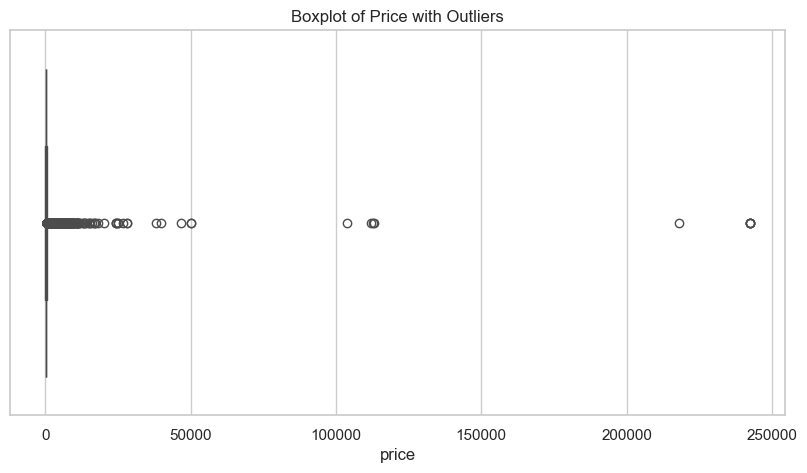

In [378]:
def get_outliers_info(df, column_name):
    Q1 = df[column_name].quantile(0.25)
    Q3 = df[column_name].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[column_name] < lower_bound) | (df[column_name] > upper_bound)]
    
    print(f"Number of outliers: {len(outliers)}")
    
    return outliers, (lower_bound, upper_bound)

price_outliers, bounds = get_outliers_info(df, 'price')

plt.figure(figsize=(10, 5))
sns.boxplot(x=df['price'])
plt.title('Boxplot of Price with Outliers')
plt.show()

## New dataframe (deleting outliers)

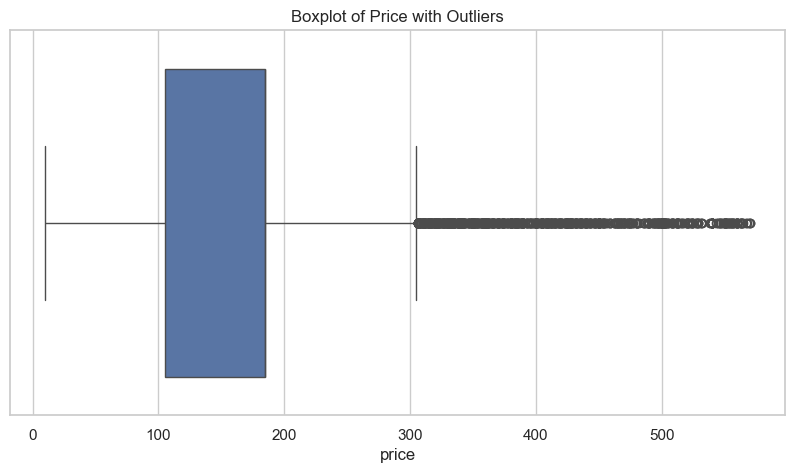

In [379]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df = df[(df['price'] >= lower_bound) & (df['price'] <= upper_bound)].copy()

df.to_csv('new_one.csv', index=False)

plt.figure(figsize=(10, 5))
sns.boxplot(x=df['price'])
plt.title('Boxplot of Price with Outliers')
plt.show()

# Distribution for price and occupancy

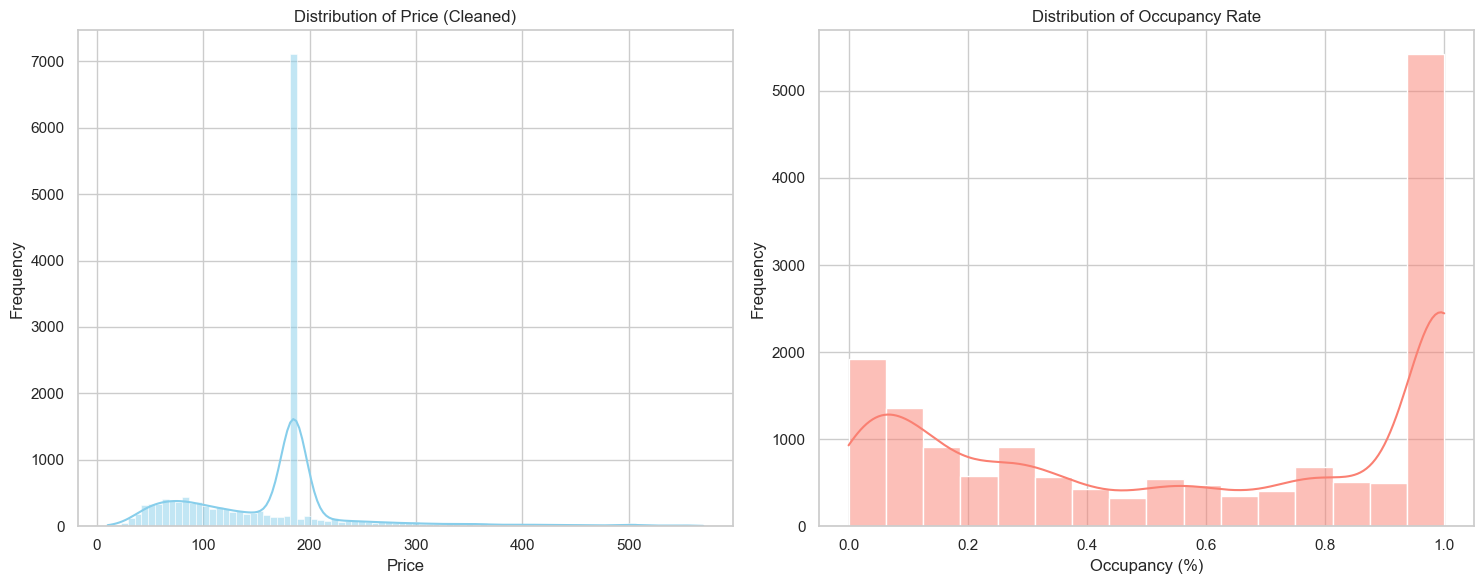

In [380]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.histplot(df['price'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Price (Cleaned)')
axes[0].set_xlabel('Price')
axes[0].set_ylabel('Frequency')

sns.histplot(df['occupancy'], kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribution of Occupancy Rate')
axes[1].set_xlabel('Occupancy (%)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# Creating linear models and working with assumptions

In [381]:

exclude_cols = ["listing_id", "host_since", "price", "occupancy", "log_price"]
X_raw = df.drop(columns=exclude_cols, errors="ignore").copy()

X = pd.get_dummies(X_raw, drop_first=True)

for col in X.columns:
    if X[col].dtype == "bool":
        X[col] = X[col].astype(int)


X = X.apply(pd.to_numeric, errors="coerce")
y_price = df["price"]
y_occupancy = df["occupancy"]

y_price_bin = (y_price > y_price.median()).astype(int)
y_occupancy_bin = (y_occupancy > y_occupancy.median()).astype(int)

data = pd.concat([X, y_price, y_occupancy, y_price_bin.rename("price_bin"), y_occupancy_bin.rename("occupancy_bin")], axis=1)
data = data.dropna().copy()

def fit_ols(y, X, name):
    X = sm.add_constant(X)
    model = sm.OLS(y, X).fit()
    print("\n" + "=" * 80)
    print(name)
    print("=" * 80)
    print(model.summary())
    return model

def fit_logit(y, X, name):
    from sklearn.linear_model import LogisticRegression
    Xc = X.copy()
    Xc = Xc.select_dtypes(include=[np.number])

    Xc = Xc.loc[:, Xc.nunique() > 1]

    temp = pd.concat([y, Xc], axis=1).dropna()
    y_clean = temp.iloc[:, 0].astype(int)
    X_clean = temp.iloc[:, 1:]

    model = LogisticRegression(
        penalty="l2",
        C=1.0,
        solver="liblinear",
        max_iter=1000
    )
    model.fit(X_clean, y_clean)

    print("\n" + "=" * 80)
    print(name)
    print("=" * 80)
    print("Intercept:")
    print(model.intercept_[0])

    print("\nCoefficients:")
    coef_table = pd.DataFrame({
        "variable": X_clean.columns,
        "coef": model.coef_[0]
    }).sort_values("coef", key=np.abs, ascending=False)

    print(coef_table.to_string(index=False))

    return model

In [382]:
# PRICE
# 1. Lin-Lin
model_price_linlin = fit_ols(data["price"], X_all, "PRICE: Lin-Lin")


PRICE: Lin-Lin
                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.353
Model:                            OLS   Adj. R-squared:                  0.334
Method:                 Least Squares   F-statistic:                     18.57
Date:                Tue, 07 Apr 2026   Prob (F-statistic):               0.00
Time:                        16:08:03   Log-Likelihood:                -89139.
No. Observations:               15867   AIC:                         1.792e+05
Df Residuals:                   15413   BIC:                         1.827e+05
Df Model:                         453                                         
Covariance Type:            nonrobust                                         
                                                                          coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------

In [383]:
# PRICE
# 2. Log-Lin
data_price_pos = data[data["price"] > 0].copy()
X_price_loglin = data_price_pos[X_all.columns]
model_price_loglin = fit_ols(np.log(data_price_pos["price"]), X_price_loglin, "PRICE: Log-Lin")


PRICE: Log-Lin
                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.450
Model:                            OLS   Adj. R-squared:                  0.434
Method:                 Least Squares   F-statistic:                     27.83
Date:                Tue, 07 Apr 2026   Prob (F-statistic):               0.00
Time:                        16:08:03   Log-Likelihood:                -8049.5
No. Observations:               15867   AIC:                         1.701e+04
Df Residuals:                   15413   BIC:                         2.049e+04
Df Model:                         453                                         
Covariance Type:            nonrobust                                         
                                                                          coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------

In [384]:
# PRICE
# 3. Lin-Log
model_price_linlog = fit_ols(data["price"], X_log, "PRICE: Lin-Log")


PRICE: Lin-Log
                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.100
Model:                            OLS   Adj. R-squared:                  0.100
Method:                 Least Squares   F-statistic:                     440.2
Date:                Tue, 07 Apr 2026   Prob (F-statistic):               0.00
Time:                        16:08:03   Log-Likelihood:                -91758.
No. Observations:               15867   AIC:                         1.835e+05
Df Residuals:                   15862   BIC:                         1.836e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const           

In [385]:
# PRICE
# 4. Log-Log
data_price_loglog = data[data["price"] > 0].copy()
X_price_loglog = data_price_loglog[log_X_cols]
model_price_loglog = fit_ols(
    np.log(data_price_loglog["price"]),
    np.log(X_price_loglog),
    "PRICE: Log-Log"
)


PRICE: Log-Log
                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.122
Model:                            OLS   Adj. R-squared:                  0.122
Method:                 Least Squares   F-statistic:                     551.4
Date:                Tue, 07 Apr 2026   Prob (F-statistic):               0.00
Time:                        16:08:04   Log-Likelihood:                -11759.
No. Observations:               15867   AIC:                         2.353e+04
Df Residuals:                   15862   BIC:                         2.357e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const           

In [386]:
# PRICE
# 5. Probability
model_price_prob = fit_ols(data["price_bin"], X_all, "PRICE: Probability")


PRICE: Probability
                            OLS Regression Results                            
Dep. Variable:              price_bin   R-squared:                       0.261
Model:                            OLS   Adj. R-squared:                  0.239
Method:                 Least Squares   F-statistic:                     12.01
Date:                Tue, 07 Apr 2026   Prob (F-statistic):               0.00
Time:                        16:08:04   Log-Likelihood:                -3715.4
No. Observations:               15867   AIC:                             8339.
Df Residuals:                   15413   BIC:                         1.182e+04
Df Model:                         453                                         
Covariance Type:            nonrobust                                         
                                                                          coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------

In [387]:
# PRICE
# 6. Logit
model_price_logit = fit_logit(data["price_bin"], X_all, "PRICE: Logit")


PRICE: Logit
Intercept:
-2.464595791612727

Coefficients:
                                                           variable      coef
                                                     city_barcelona -7.034334
                                neighbourhood_cleansed_Innere Stadt  2.184110
                                                     city_stockholm  2.040324
                                                        city_london -1.770089
                            neighbourhood_cleansed_I Centro Storico  1.743615
                              neighbourhood_cleansed_Rinkeby-Tensta  1.551451
                      neighbourhood_cleansed_Kensington and Chelsea  1.436787
                      neighbourhood_cleansed_ΕΜΠΟΡΙΚΟ ΤΡΙΓΩΝΟ-ΠΛΑΚΑ  1.392251
                                  neighbourhood_cleansed_Södermalms -1.358232
                                                          city_rome -1.343428
                      neighbourhood_cleansed_la Dreta de l'Eixample -1.312121
     

In [388]:
# OCCUPANCY
# 1. Lin-Lin
model_occ_linlin = fit_ols(data["occupancy"], X_all, "OCCUPANCY: Lin-Lin")


OCCUPANCY: Lin-Lin
                            OLS Regression Results                            
Dep. Variable:              occupancy   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 2.690e+04
Date:                Tue, 07 Apr 2026   Prob (F-statistic):               0.00
Time:                        16:08:05   Log-Likelihood:                 45554.
No. Observations:               15867   AIC:                        -9.020e+04
Df Residuals:                   15413   BIC:                        -8.672e+04
Df Model:                         453                                         
Covariance Type:            nonrobust                                         
                                                                          coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------

In [389]:
# OCCUPANCY
# 2. Log-Lin
data_occ_pos = data[data["occupancy"] > 0].copy()
X_occ_loglin = data_occ_pos[X_all.columns]
model_occ_loglin = fit_ols(np.log(data_occ_pos["occupancy"]), X_occ_loglin, "OCCUPANCY: Log-Lin")


OCCUPANCY: Log-Lin
                            OLS Regression Results                            
Dep. Variable:              occupancy   R-squared:                       0.804
Model:                            OLS   Adj. R-squared:                  0.798
Method:                 Least Squares   F-statistic:                     137.9
Date:                Tue, 07 Apr 2026   Prob (F-statistic):               0.00
Time:                        16:08:05   Log-Likelihood:                -13333.
No. Observations:               15536   AIC:                         2.756e+04
Df Residuals:                   15087   BIC:                         3.100e+04
Df Model:                         448                                         
Covariance Type:            nonrobust                                         
                                                                          coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------

In [390]:
# OCCUPANCY
# 3. Lin-Log
model_occ_linlog = fit_ols(data["occupancy"], X_log, "OCCUPANCY: Lin-Log")


OCCUPANCY: Lin-Log
                            OLS Regression Results                            
Dep. Variable:              occupancy   R-squared:                       0.190
Model:                            OLS   Adj. R-squared:                  0.190
Method:                 Least Squares   F-statistic:                     932.2
Date:                Tue, 07 Apr 2026   Prob (F-statistic):               0.00
Time:                        16:08:05   Log-Likelihood:                -5719.7
No. Observations:               15867   AIC:                         1.145e+04
Df Residuals:                   15862   BIC:                         1.149e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const       

In [391]:
# OCCUPANCY
# 4. Log-Log
data_occ_loglog = data[data["occupancy"] > 0].copy()
X_occ_loglog = data_occ_loglog[log_X_cols]
model_occ_loglog = fit_ols(
    np.log(data_occ_loglog["occupancy"]),
    np.log(X_occ_loglog),
    "OCCUPANCY: Log-Log"
)


OCCUPANCY: Log-Log
                            OLS Regression Results                            
Dep. Variable:              occupancy   R-squared:                       0.118
Model:                            OLS   Adj. R-squared:                  0.118
Method:                 Least Squares   F-statistic:                     519.1
Date:                Tue, 07 Apr 2026   Prob (F-statistic):               0.00
Time:                        16:08:05   Log-Likelihood:                -25006.
No. Observations:               15536   AIC:                         5.002e+04
Df Residuals:                   15531   BIC:                         5.006e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const       

In [392]:
# OCCUPANCY
# 5. Probability
model_occ_prob = fit_ols(data["occupancy_bin"], X_all, "OCCUPANCY: Probability")


OCCUPANCY: Probability
                            OLS Regression Results                            
Dep. Variable:          occupancy_bin   R-squared:                       0.856
Model:                            OLS   Adj. R-squared:                  0.852
Method:                 Least Squares   F-statistic:                     201.8
Date:                Tue, 07 Apr 2026   Prob (F-statistic):               0.00
Time:                        16:08:06   Log-Likelihood:                 3844.7
No. Observations:               15867   AIC:                            -6781.
Df Residuals:                   15413   BIC:                            -3298.
Df Model:                         453                                         
Covariance Type:            nonrobust                                         
                                                                          coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------

In [ ]:
# OCCUPANCY
# 6. Logit
model_occ_logit = fit_logit(data["occupancy_bin"], X_all, "OCCUPANCY: Logit")


OCCUPANCY: Logit
Intercept:
1.5897587939441309

Coefficients:
                                                           variable          coef
                                                     city_barcelona  3.069576e+00
                                                          city_rome  1.613724e+00
                                                        city_athens  1.469090e+00
                                                        city_berlin -1.407186e+00
                                                     city_stockholm -1.146920e+00
                                                    city_copenhagen -9.515387e-01
                            neighbourhood_cleansed_I Centro Storico  7.180229e-01
                                         property_type_Entire condo  6.639342e-01
                                                        city_london  5.454357e-01
                                               review_scores_rating  5.339575e-01
                      neighbourhood

In [ ]:
df["instant_bookable"] = df["instant_bookable"].fillna("f")
df["instant_bookable"] = df["instant_bookable"].map({'t': 1, 'f': 0})

In [ ]:
df = df[df['price'] != 185.0]

In [ ]:
# inroduce variable distance to city center (calculate distance using latitude and longitude)
# city centers coordinates for distance calculation
cities_coords = {
    'amsterdam': {'latitude': 52.3791, 'longitude': 4.9003}, 
    'athens': {'latitude': 37.9657, 'longitude': 23.7391}, 
    'barselona': {'latitude': 41.3851, 'longitude': 2.1734}, 
    'berlin': {'latitude': 52.52, 'longitude': 13.405}, 
    'copenhagen': {'latitude': 55.6761, 'longitude': 12.5683}, 
    'london': {'latitude': 51.5074, 'longitude': 0.1272}, 
    'prague': {'latitude': 50.0755, 'longitude': 14.4378}, 
    'rome': {'latitude': 41.9029, 'longitude': 12.4964}, 
    'stockholm': {'latitude': 59.3293, 'longitude': 18.0686}, 
    'vienna': {'latitude': 48.2336, 'longitude': 16.4171}
}

# calculate distance from each listing to city center
def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in kilometers
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    delta_phi = np.radians(lat2 - lat1)
    delta_lambda = np.radians(lon2 - lon1)
    
    a = np.sin(delta_phi / 2)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(delta_lambda / 2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    
    return R * c

distances = []
for index, row in df.iterrows():
    city = row['city']
    if city in cities_coords:
        city_lat = cities_coords[city]['latitude']
        city_lon = cities_coords[city]['longitude']
        distance = haversine_distance(row['latitude'], row['longitude'], city_lat, city_lon)
        distances.append(distance)
    else:
        distances.append(np.nan)  # If city is not in the list, assign NaN

df['distance_to_city_center'] = distances
df['distance_to_city_center'] = df['distance_to_city_center'].fillna(df['distance_to_city_center'].median())

In [ ]:
# add dummies for room type
prop_type_dummies = pd.get_dummies(df['room_type'], prefix='room_type', dtype=int)
# add dummies to the main dataframe
df = pd.concat([df, prop_type_dummies], axis=1)

room_type_params = list(prop_type_dummies.columns)[:-1]

# add dummies for cities
city_dummies = pd.get_dummies(df['city'], prefix='city', dtype=int)
df = pd.concat([df, city_dummies], axis=1)
city_params = list(city_dummies.columns)[:-1]

df = df.loc[:, ~df.columns.duplicated()]

In [ ]:
# test the joint significance of cities on log price
X_cities = df[city_params]
X_cities = sm.add_constant(X_cities)
model_cities = sm.OLS(df['log_price'], X_cities).fit()
print(model_cities.summary())

In [ ]:
# introduce variable log_delta_price that corresponds to the difference between log price and log of median price in the city
median_log_price_by_city = df.groupby('city')['log_price'].transform('median')
df['log_delta_price'] = df['log_price'] - median_log_price_by_city

In [ ]:
# define variables for initial model
# parameters of property characteristics
prop_params = ['bathrooms', 'bedrooms', 'beds', 'minimum_nights', 'instant_bookable', 'occupancy', 'accommodates'] 
prop_params += room_type_params

# parameters of host characteristics
host_params = ['host_total_listings_count', 'host_tenure_days', 'host_is_superhost']

# parameters of reviews characteristics
reviews_params = ['number_of_reviews', 'review_scores_rating', 'reviews_last_year', 'reviews_per_month']

# parameters of location characteristics
loc_params = ['distance_to_city_center']

In [ ]:
# build model for log_delta_price with all parameters 

X = df[prop_params + host_params + reviews_params + loc_params]
X = sm.add_constant(X)
model = sm.OLS(df['log_delta_price'], X).fit()
print(model.summary())

In [ ]:
aic = {}
y = df["log_delta_price"]
params = prop_params + host_params + reviews_params + loc_params
eliminated_vars = []
while True:
    x = df[params]
    x = sm.add_constant(x)
    model_current = sm.OLS(y, x).fit()
    aic["baseline"] =  model_current.aic
    for col in df[params]:
        y = df["log_delta_price"]
        candidate_params = params.copy()
        candidate_params.remove(col)
        x = df[candidate_params]
        x = sm.add_constant(x)
        model_cand = sm.OLS(y, x).fit()
        aic[col] = model_cand.aic

    aic_sorted = dict(sorted(aic.items(), key=lambda item: item[1]))
    best_var_to_remove = list(aic_sorted.keys())[0]
    best_aic = aic_sorted[best_var_to_remove]
    current_aic = aic_sorted["baseline"]
    if best_aic < current_aic:
        params.remove(best_var_to_remove)
        eliminated_vars.append({
                'excluded_variable': best_var_to_remove,
                'p_value_at_excluding': model_current.pvalues[best_var_to_remove],
                'AIC_before': current_aic,
                'AIC_after': best_aic
            })
    else:
        break

result_df = pd.DataFrame(eliminated_vars)

result_df


In [ ]:
model = sm.OLS(df['log_delta_price'], sm.add_constant(df[params])).fit()
print(model.summary())

In [ ]:
par = params.copy()
par.remove('number_of_reviews')
# par.remove('host_tenure_days')

In [ ]:
model = sm.OLS(df['log_delta_price'], sm.add_constant(df[par])).fit()
print(model.summary())